<a href="https://colab.research.google.com/github/AnalyticPalmer/Multiple-Linear-Regression/blob/main/Multiple_Linear_Regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Multiple Linear Regression – Multi-Channel Marketing Analysis

## Project Overview

### This project focuses on predicting **Sales** using multiple marketing channels simultaneously. Unlike Simple Linear Regression, Multiple Linear Regression allows us to measure the impact of several independent variables while controlling for the effects of others.

### The dataset contains:

| Variable     | Description                             |
| ------------ | --------------------------------------- |
| TV           | TV advertising spend category           |
| Radio        | Radio advertising spend                 |
| Social Media | Social media advertising spend          |
| Influencer   | Influencer marketing category           |
| Sales        | Total sales generated (Target Variable) |


# Import Required Libraries

In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import statsmodels.api as sm

from statsmodels.stats.outliers_influence import variance_inflation_factor
from scipy import stats


# Load the Dataset

In [ ]:
df = pd.read_csv('marketing_sales_data.csv')

df.head()

,TV,Radio,Social Media,Influencer,Sales
0,Low,3.518070,2.293790,Micro,55.261284
1,Low,7.756876,2.572287,Mega,67.574904
2,High,20.348988,1.227180,Micro,272.250108
3,Medium,20.108487,2.728374,Mega,195.102176
4,High,31.653200,7.776978,Nano,273.960377


# Initial Exploratory Data Analysis (EDA)

### Dataset Shape

In [ ]:
df.shape

(572, 5)

### Dataset Information

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 572 entries, 0 to 571
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   TV            572 non-null    object 
 1   Radio         572 non-null    float64
 2   Social Media  572 non-null    float64
 3   Influencer    572 non-null    object 
 4   Sales         572 non-null    float64
dtypes: float64(3), object(2)
memory usage: 22.5+ KB


### Missing Values

In [ ]:
df.isnull().sum()

TV              0
Radio           0
Social Media    0
Influencer      0
Sales           0
dtype: int64

### Statistical Summary

In [ ]:
df.describe()

,Radio,Social Media,Sales
count,572.000000,572.000000,572.000000
mean,17.520616,3.333803,189.296908
std,9.290933,2.238378,89.871581
min,0.109106,0.000031,33.509810
25%,10.699556,1.585549,118.718722
50%,17.149517,3.150111,184.005362
75%,24.606396,4.730408,264.500118
max,42.271579,11.403625,357.788195


### Check Categorical Variables

In [ ]:
df['TV'].value_counts()

df['Influencer'].value_counts()

Influencer
Nano     157
Micro    151
Mega     137
Macro    127
Name: count, dtype: int64

# Data Preprocessing
### Since TV and Influencer are categorical variables, they must be converted into numerical format.

In [ ]:
df_encoded = pd.get_dummies(
    df,
    columns=['TV', 'Influencer'],
    drop_first=True
)

df_encoded.head()

,Radio,Social Media,Sales,TV_Low,TV_Medium,Influencer_Mega,Influencer_Micro,Influencer_Nano
0,3.518070,2.293790,55.261284,True,False,False,True,False
1,7.756876,2.572287,67.574904,True,False,True,False,False
2,20.348988,1.227180,272.250108,False,False,False,True,False
3,20.108487,2.728374,195.102176,False,True,True,False,False
4,31.653200,7.776978,273.960377,False,False,False,False,True


# Correlation Matrix

### A correlation matrix helps identify relationships among predictors.


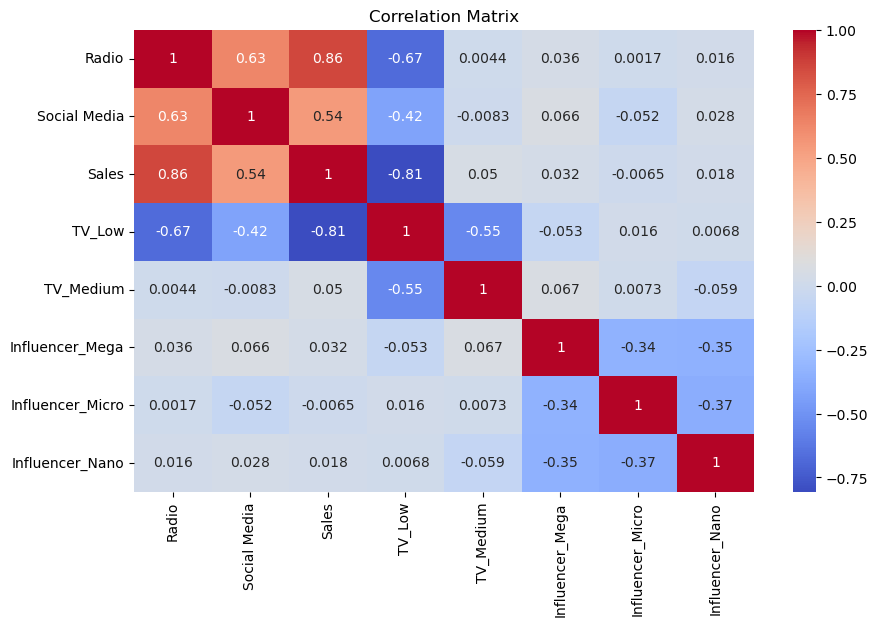

In [ ]:
plt.figure(figsize=(10,6))

sns.heatmap(
    df_encoded.corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title('Correlation Matrix')
plt.show()

### Interpretation

### * Strong correlations between predictors may indicate multicollinearity.
### * Very high correlations (>0.8) require further investigation.

# Check Multicollinearity Using VIF

### Variance Inflation Factor (VIF) measures how much a variable is explained by other predictors.

### Prepare Features

In [ ]:
X = df_encoded.drop('Sales', axis=1)

X = sm.add_constant(X)

### Calculate VIF

In [ ]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
import pandas as pd
import statsmodels.api as sm

# Features only
X = df_encoded.drop('Sales', axis=1)

# Convert all columns to numeric
X = X.astype(float)

# Add constant
X = sm.add_constant(X)

# Calculate VIF
vif_data = pd.DataFrame()

vif_data["Feature"] = X.columns

vif_data["VIF"] = [
    variance_inflation_factor(X.values, i)
    for i in range(X.shape[1])
]

print(vif_data)

            Feature        VIF
0             const  31.649565
1             Radio   3.479641
2      Social Media   1.669098
3            TV_Low   4.076384
4         TV_Medium   2.233350
5   Influencer_Mega   1.593889
6  Influencer_Micro   1.618434
7   Influencer_Nano   1.627430


### VIF Interpretation

| VIF  | Meaning                   |
| ---- | ------------------------- |
| 1-5  | Acceptable                |
| 5-10 | Moderate concern          |
| >10  | Serious multicollinearity |

### Results

| Variable             | VIF  |
| -------------------- | ---- |
| Radio                | 3.48 |
| Social Media         | 1.67 |
| TV_Low               | 4.08 |
| TV_Medium            | 2.23 |
| Influencer Variables | ~1.6 |

### **Conclusion:** No severe multicollinearity exists in the dataset.


# Build Multiple Linear Regression Model

### Define Features and Target


In [ ]:
X = df_encoded.drop('Sales', axis=1)

y = df_encoded['Sales']

X = sm.add_constant(X)

### Train Model

In [ ]:
# Features
X = df_encoded.drop('Sales', axis=1)

# Target
y = df_encoded['Sales']

# Convert everything to numeric
X = X.astype(float)
y = y.astype(float)

# Add intercept
X = sm.add_constant(X)

# Fit model
model = sm.OLS(y, X).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                  Sales   R-squared:                       0.904
Model:                            OLS   Adj. R-squared:                  0.903
Method:                 Least Squares   F-statistic:                     760.4
Date:                Thu, 11 Jun 2026   Prob (F-statistic):          1.82e-282
Time:                        10:42:44   Log-Likelihood:                -2713.4
No. Observations:                 572   AIC:                             5443.
Df Residuals:                     564   BIC:                             5478.
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const              217.4784      6.584  

# Model Evaluation

## Adjusted R-Squared

In [ ]:
print("Adjusted R-Squared:", model.rsquared_adj)

Adjusted R-Squared: 0.9030011006551627


### Result

```text
Adjusted R² = 0.903
```

### Interpretation

### The model explains approximately **90.3% of the variation in Sales**, indicating excellent predictive performance

## Predictor Significance (P-values)

In [ ]:
model.pvalues

const               5.906914e-134
Radio                1.943682e-32
Social Media         8.371166e-01
TV_Low              4.536854e-125
TV_Medium            2.277532e-71
Influencer_Mega      4.714413e-01
Influencer_Micro     3.845913e-01
Influencer_Nano      8.107454e-01
dtype: float64

### Significant Variables

| Variable  | P-value |
| --------- | ------- |
| Radio     | < 0.05  |
| TV_Low    | < 0.05  |
| TV_Medium | < 0.05  |

### Not Significant

| Variable              | P-value |
| --------------------- | ------- |
| Social Media          | > 0.05  |
| Influencer Categories | > 0.05  |

### Interpretation

### * Radio spending significantly impacts sales.
### * TV advertising level significantly impacts sales.
### * Social Media spending is not statistically significant.
### * Influencer category is not statistically significant.


# Residual Diagnostics

## A. Linearity Check

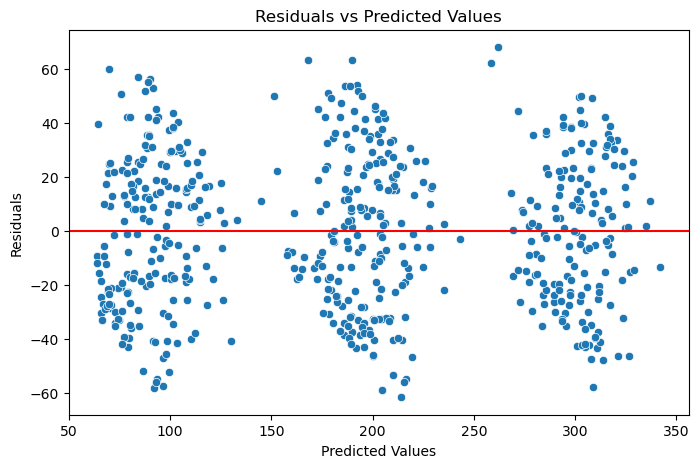

In [ ]:
predictions = model.predict(X)

residuals = y - predictions

plt.figure(figsize=(8,5))

sns.scatterplot(
    x=predictions,
    y=residuals
)

plt.axhline(0, color='red')

plt.xlabel('Predicted Values')
plt.ylabel('Residuals')

plt.title('Residuals vs Predicted Values')
plt.show()

### Expected Outcome

### Residuals should appear randomly scattered around zero.

## B. Normality Check

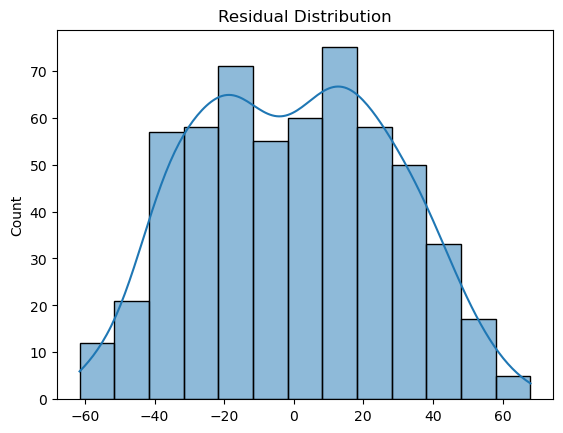

In [ ]:
sns.histplot(
    residuals,
    kde=True
)

plt.title('Residual Distribution')
plt.show()

### Q-Q Plot

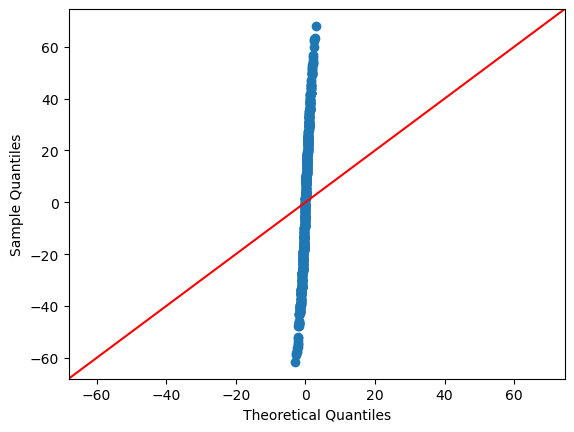

In [ ]:
sm.qqplot(
    residuals,
    line='45'
)

plt.show()

### Expected Outcome

### Points should follow the diagonal line closely.

## C. Homoscedasticity Check

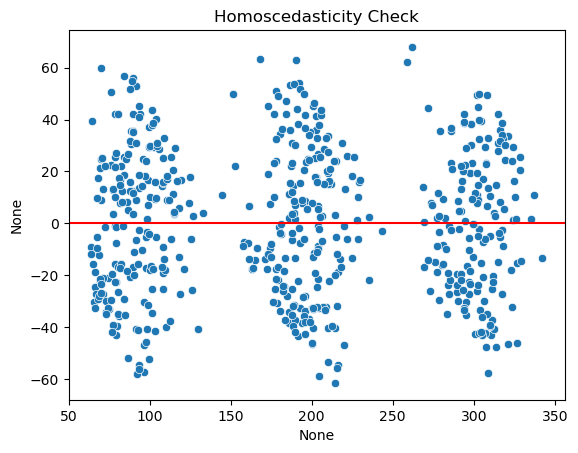

In [ ]:
sns.scatterplot(
    x=predictions,
    y=residuals
)

plt.axhline(0, color='red')

plt.title('Homoscedasticity Check')
plt.show()


### Expected Outcome

### Residual spread should remain fairly constant across predictions.

# Coefficient Interpretation

### Radio

### Coefficient ≈ **2.97**

### Interpretation:

> Holding TV and Social Media spending constant, every additional 1-unit increase in Radio advertising spend is associated with approximately 2.97 additional units of Sales.

### TV Categories

### TV spending level has a substantial effect on Sales.

### Compared to the baseline TV category:

### * Low TV spend reduces expected Sales significantly.
### * Medium TV spend also reduces Sales, though less severely.
### * High TV spend generates the strongest sales performance.

### Social Media

### Coefficient ≈ **-0.14**

### Interpretation:

> After accounting for TV and Radio advertising, Social Media spending shows no statistically significant effect on Sales.


# Business Recommendations

## Key Findings

### 1. Prioritize TV Advertising

### TV spending shows the strongest relationship with Sales.

### 2. Continue Investing in Radio

### Radio advertising has a statistically significant positive effect on Sales.

### 3. Reevaluate Social Media Spending

### Social Media spend does not significantly improve Sales within this dataset.

### 4. Reassess Influencer Campaigns

### Influencer categories do not significantly impact Sales and may not provide strong ROI.


# Final Conclusion

### The Multiple Linear Regression model achieved an **Adjusted R² of 90.3%**, indicating excellent explanatory power. Multicollinearity was not a concern, as all VIF values remained below critical thresholds. Statistical testing revealed that **TV and Radio advertising are the primary drivers of Sales**, while **Social Media and Influencer marketing showed limited predictive value**.

### Based on the evidence, marketing budgets should prioritize **TV advertising first**, followed by **Radio**, while carefully reviewing expenditures on **Social Media and Influencer campaigns** to maximize return on investment.
